# 1. Setting Up
This is to initialize all necessary requirements and dataset used for the DATAMIN Finals project.

In [57]:
# Run this if you don't have the libraries installed
# This was added for those that are running the notebook 
# in a new environment and don't have the libraries installed yet. 
# You can skip this out if you already have them installed.

%pip install numpy
%pip install pandas
%pip install matplotlib
%pip install scikit-learn


Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [58]:
# This imports all the libraries we need for this notebook.
import re
import numpy as np
import pandas as pd

# This is for plotting graphs and visualizations.
import matplotlib.pyplot as plt

# Prepare features for clustering
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# This is just to make sure that when we print out dataframes, 
# we can see all the columns and the full width of the dataframe.
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)


In [59]:
# This reads in the data from the CSV file and gives us a quick 
# look at the first 10 rows. The info about the dataframe, 
# and checks for any missing values.
# This is optional.

df = pd.read_csv("./data/IBP_OBS_Data_Launch2-OBS_Data_2006-2025.csv")

display(df.head(5))

,country,ISO,year,region,comp_region,obi,roundobi,obi_cat,obi_cat2,obi_cat3,obi_cat4,oversight_obi,roundoversight_obi,grade_oversight,leg_obi,roundleg_obi,grade_leg,sai_obi,roundsai_obi,grade_sai,ifi_obi,roundifi_obi,grade_ifi,pub_eng,roundpub_eng,grade_pub_eng,pbs,ebp,eb,iyr,myr,yer,ar,cb,pub_pbs,pub_ebp,pub_eb,pub_cb,pub_iyr,pub_myr,pub_yer,pub_ar,obi_pbs,roundobi_pbs,obi_pbs_cat,obi_ebp,roundobi_ebp,obi_ebp_cat,obi_eb,roundobi_eb,...,q110,q111,q112,q113,q114,q115,q116,q117,q118,q119,q120,q121,q122,q123,q124,q125,q126,q127,q128,q129,q130,q131,q132,q133,q134,q135,q136,q137,q138,q139,q140,q141,q142,t3pbs,t3ebp,t3eb,t3iyr,t3myr,t3yer,t3ar,new25,comp0612,comp0812,comp1012,comp1215,comp1517,comp1719,comp1921,comp2123,comp2325
0,Albania,ALB,2025,Eastern Europe & Central Asia,Western Balkans & Turkiye,64.229358,64,Substantial (61-80),Sufficient (61-100),Sufficient (61-100),4th Quintile,68.555556,69.0,Adequate (61-100),63.916667,64,Adequate (61-100),77.833333,78,Adequate (61-100),0.0,0.0,Weak (0-40),16.611111,17.0,Few or no opportunities (0-40),PW,PW,PW,PW,PW,PW,PW,PW,1,1,1,1,1,1,1,1,94.5,95,Extensive (81-100),61.703704,62,Substantial (61-80),94.5,95,...,100.0,100.0,67.0,67.0,0,0.0,100.0,100,33,100,100.0,100.0,100.0,0.0,67.0,33.0,0,33,0,0,0.0,0.0,0.0,0.0,100.0,33.0,67.0,33.0,0.0,0.0,0.0,0.0,0.0,100,67,67.0,67,100.0,100,67,0,1.0,1.0,1.0,1.0,1,1,1,1,1
1,Albania,ALB,2023,Eastern Europe & Central Asia,Western Balkans & Turkiye,57.477064,57,Limited (41-60),Limited (41-60),Insufficient (0-60),Middle Quintile,66.666667,67.0,Adequate (61-100),63.916667,64,Adequate (61-100),72.166667,72,Adequate (61-100),0.0,0.0,Weak (0-40),9.166667,9.0,Few or no opportunities (0-40),PW,PW,PW,PW,PW,PW,PW,IU,1,1,1,0,1,1,1,1,94.5,95,Extensive (81-100),58.592593,59,Limited (41-60),94.5,95,...,100.0,100.0,67.0,67.0,0,0.0,100.0,100,33,100,100.0,100.0,100.0,0.0,33.0,33.0,0,33,0,0,0.0,0.0,0.0,0.0,0.0,33.0,33.0,33.0,0.0,0.0,0.0,0.0,0.0,100,67,67.0,33,100.0,33,67,0,1.0,1.0,1.0,1.0,1,1,1,1,1
2,Albania,ALB,2021,Eastern Europe & Central Asia,Western Balkans & Turkiye,51.651376,52,Limited (41-60),Limited (41-60),Insufficient (0-60),Middle Quintile,66.666667,67.0,Adequate (61-100),63.916667,64,Adequate (61-100),72.166667,72,Adequate (61-100),0.0,0.0,Weak (0-40),5.500000,6.0,Few or no opportunities (0-40),PW,PW,PW,PW,PW,PW,PL,PW,1,1,1,1,1,1,1,0,94.5,95,Extensive (81-100),53.037037,53,Limited (41-60),94.5,95,...,100.0,100.0,67.0,67.0,0,0.0,100.0,100,33,100,100.0,100.0,100.0,0.0,33.0,0.0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,33.0,33.0,33.0,0.0,0.0,0.0,0.0,0.0,100,67,67.0,33,100.0,33,0,0,1.0,1.0,1.0,1.0,1,1,1,1,1
3,Albania,ALB,2019,Eastern Europe & Central Asia,Western Balkans & Turkiye,54.715596,55,Limited (41-60),Limited (41-60),Insufficient (0-60),Middle Quintile,64.777778,65.0,Adequate (61-100),61.083333,61,Adequate (61-100),72.166667,72,Adequate (61-100),0.0,0.0,Weak (0-40),7.333333,7.0,Few or no opportunities (0-40),PW,PW,PW,PW,PW,PW,PW,PW,1,1,1,1,1,1,1,1,94.5,95,Extensive (81-100),49.351852,49,Limited (41-60),100.0,100,...,100.0,100.0,67.0,33.0,0,0.0,100.0,100,100,100,100.0,100.0,100.0,0.0,33.0,0.0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,33.0,33.0,33.0,33.0,0.0,0.0,0.0,0.0,100,67,100.0,100,100.0,67,67,0,1.0,1.0,1.0,1.0,1,1,1,1,1
4,Albania,ALB,2017,Eastern Europe & Central Asia,Western Balkans & Turkiye,49.657407,50,Limited (41-60),Limited (41-60),Insufficient (0-60),Middle Quintile,68.500000,69.0,Adequate (61-100),66.666667,67,Adequate (61-100),72.166667,72,Adequate (61-100),0.0,0.0,Weak (0-40),1.833333,2.0,Few or No (0-40),PW,PW,PW,PW,NP,PW,PW,PW,1,1,1,1,1,0,1,1,94.5,95,Extensive (81-100),49.000000,49,Limited (41-60),89.0,89,...,100.0,100.0,67.0,33.0,33,0.0,100.0,100,100,100,100.0,100.0,100.0,0.0,33.0,0.0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,33.0,0.0,0.0,0.0,0.0,0.0,0.0,100,33,67.0,33,0.0,33,67,0,1.0,1.0,1.0,1.0,1,1,1,1,1


In [60]:
## Simple check to see what the data looks like, and if there are any missing values.

df.info()
df.isna().sum()

<class 'pandas.DataFrame'>
RangeIndex: 257 entries, 0 to 256
Columns: 240 entries, country to comp2325
dtypes: float64(110), int64(85), str(45)
memory usage: 482.0 KB


country        0
ISO            0
year           0
region         0
comp_region    0
              ..
comp1517       0
comp1719       0
comp1921       0
comp2123       0
comp2325       0
Length: 240, dtype: int64

# 2. Selecting Necessary Data
After all the setup, the next step is to filter out all unecessary data. This is to limit all the information that will be presented to only ones that are necessary for analysis.

In [61]:
# Select only the columns needed for analysis
# Keeping identifiers, core scores, and comparability flags

selected_columns = [
    'country',           # Country name
    'ISO',               # Country code
    'year',              # Survey year
    'region',            # Broad region
    'comp_region',       # Detailed region
    'obi',               # Transparency score (0-100)
    'oversight_obi',     # Oversight score (0-100)
    'pub_eng',           # Public participation score (0-100)
    'comp1215',          # Comparability from 2012 onward
    'comp1517',          # Comparability from 2015 onward
    'comp1719',          # Comparability from 2017 onward
    'comp1921',          # Comparability from 2019 onward
    'comp2123',          # Comparability from 2021 onward
    'comp2325'           # Comparability from 2023 onward
]

# Create a new dataframe with only the selected columns
df_selected = df[selected_columns].copy()

# Display first few rows to verify
print("Selected columns shape:", df_selected.shape)
display(df_selected.head())

Selected columns shape: (257, 14)


,country,ISO,year,region,comp_region,obi,oversight_obi,pub_eng,comp1215,comp1517,comp1719,comp1921,comp2123,comp2325
0,Albania,ALB,2025,Eastern Europe & Central Asia,Western Balkans & Turkiye,64.229358,68.555556,16.611111,1.0,1,1,1,1,1
1,Albania,ALB,2023,Eastern Europe & Central Asia,Western Balkans & Turkiye,57.477064,66.666667,9.166667,1.0,1,1,1,1,1
2,Albania,ALB,2021,Eastern Europe & Central Asia,Western Balkans & Turkiye,51.651376,66.666667,5.500000,1.0,1,1,1,1,1
3,Albania,ALB,2019,Eastern Europe & Central Asia,Western Balkans & Turkiye,54.715596,64.777778,7.333333,1.0,1,1,1,1,1
4,Albania,ALB,2017,Eastern Europe & Central Asia,Western Balkans & Turkiye,49.657407,68.500000,1.833333,1.0,1,1,1,1,1


# 3. Data Cleaning & Saving
Normalizing all data variables (if given dataset is dirty)

*Dirty data just means data that may have appeared multiple times in different forms Ex. Male, M, m, male*<br/>
*Null values are also dirty data due to how it should be handled when analyzing given data*<br/>
*Removal of duplicate entries and many more also also considered ion this step*

Save the cleaned dataset when it has been fully adjusted.

*This step is ONLY necessary if the given dataset is not normalized*

In [62]:
# Convert numeric columns from string/object to proper numeric types
# This ensures calculations work correctly

numeric_columns = ['obi', 'oversight_obi', 'pub_eng']

for col in numeric_columns:
    df_selected[col] = pd.to_numeric(df_selected[col], errors='coerce')

# Check for missing values in key columns
print("Missing values in key columns:")
print(df_selected[numeric_columns].isna().sum())

# Optional: Drop rows where obi is missing (if needed for analysis)
# df_clean = df_selected.dropna(subset=['obi'])

# Save the cleaned dataset to a new CSV file
df_selected.to_csv('./data/IBP_OBS_cleaned.csv', index=False)
print("Cleaned dataset saved to './data/IBP_OBS_cleaned.csv'")

display(df_selected.head())

# Quick summary statistics
print("\nSummary statistics for key scores (2006-2025):")
print(df_selected[numeric_columns].describe())

Missing values in key columns:
obi                0
oversight_obi    115
pub_eng           64
dtype: int64
Cleaned dataset saved to './data/IBP_OBS_cleaned.csv'


,country,ISO,year,region,comp_region,obi,oversight_obi,pub_eng,comp1215,comp1517,comp1719,comp1921,comp2123,comp2325
0,Albania,ALB,2025,Eastern Europe & Central Asia,Western Balkans & Turkiye,64.229358,68.555556,16.611111,1.0,1,1,1,1,1
1,Albania,ALB,2023,Eastern Europe & Central Asia,Western Balkans & Turkiye,57.477064,66.666667,9.166667,1.0,1,1,1,1,1
2,Albania,ALB,2021,Eastern Europe & Central Asia,Western Balkans & Turkiye,51.651376,66.666667,5.500000,1.0,1,1,1,1,1
3,Albania,ALB,2019,Eastern Europe & Central Asia,Western Balkans & Turkiye,54.715596,64.777778,7.333333,1.0,1,1,1,1,1
4,Albania,ALB,2017,Eastern Europe & Central Asia,Western Balkans & Turkiye,49.657407,68.500000,1.833333,1.0,1,1,1,1,1



Summary statistics for key scores (2006-2025):
              obi  oversight_obi     pub_eng
count  257.000000     142.000000  193.000000
mean    46.702368      54.731244   15.355317
std     20.461774      16.316036   13.412515
min      0.728261      11.055556    0.000000
25%     36.082569      46.277778    5.555556
50%     48.899101      55.500000   12.944444
75%     61.458716      62.930556   22.166667
max     84.738318      90.777778   75.062500


# 4. Data Analysis

Global average OBI score by year (excluding pilot):
   year        obi
0  2006  41.632394
1  2008  42.064311
2  2010  45.133777
3  2012  44.282660
4  2015  46.667721
5  2017  48.890075
6  2019  49.591729
7  2021  50.057227
8  2023  46.934415
9  2025  49.933655


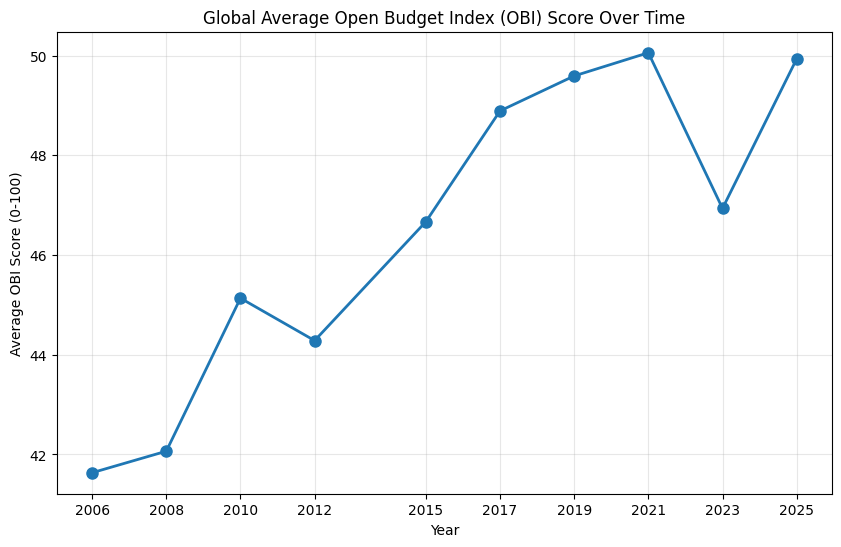

In [74]:
# Calculate global average OBI score per year
# Exclude the problematic '2023_pilot' year

# Filter out pilot year
df_trend = df_selected[df_selected['year'] != '2023_pilot'].copy()

# Convert year to numeric if needed
df_trend['year'] = pd.to_numeric(df_trend['year'])

# Calculate yearly average FROM THE FILTERED DATA
yearly_avg = df_trend.groupby('year')['obi'].mean().reset_index()

print("Global average OBI score by year (excluding pilot):")
print(yearly_avg)

# Create the plot
plt.figure(figsize=(10, 6))
plt.plot(yearly_avg['year'], yearly_avg['obi'], marker='o', linewidth=2, markersize=8)

# Set x-axis to show only the years that exist in the data
plt.xticks(yearly_avg['year'])  # This ensures only 2006, 2008, 2010, etc. show

plt.title('Global Average Open Budget Index (OBI) Score Over Time')
plt.xlabel('Year')
plt.ylabel('Average OBI Score (0-100)')
plt.grid(True, alpha=0.3)
plt.show()